This is a classification model that is trained to predict if an image has good quality for the lipids to even be segmented.

In [62]:
from fastai.vision.all import *
from utils import (
    generic_image_path,
    generic_image_path_processed,
    generic_segmentation_path,
    generic_segmentation_path_processed,
    paste_imgs,
)
np.int = np.int32 # Need to add this to make preset model work

In [63]:
# In order to not keep changing the folder names in the utils file. I organized the "data/" folder to be inside different resolution scenario folders.
# So revise the root path assigned when necessary.
root = Path("../test_lipid_classification")

# df = pd.read_csv("metadata.csv")
df = pd.read_csv("../test_lipid_classification/metadata_uvp6_lipid.csv")

image_path_processed = generic_image_path_processed(root)

def label_func(p:Path):
    return segmentation_path_processed(p.name)

df['image_file_processed'] = df.filename.apply(image_path_processed)

# print(df[1:5])

### Training

In [64]:
# Create a new data block that is a categoryblock instead of a maskblock
dls =  DataBlock(
    blocks=(ImageBlock,CategoryBlock),
    get_x = ColReader("image_file_processed"),
    get_y = ColReader("label"),

    # need to convert all images to the same size
    item_tfms=Resize(224, method=ResizeMethod.Pad, pad_mode='zeros'), # aparently 224x224 is optimal for resnet34

    # TODO Add a batch norm?
    batch_tfms=[Normalize.from_stats(*imagenet_stats), *aug_transforms(pad_mode='zeros', max_rotate=180)],
    
    splitter=RandomSplitter(valid_pct=0.8, seed=88)
    # splitter=ColSplitter("is_valid"),
).dataloaders(df, batch_size=8, drop_last=True)

Due to IPython and Windows limitation, python multiprocessing isn't available now.
So `number_workers` is changed to 0 to avoid getting stuck


C:\Users\patri\anaconda3\envs\loki-inference\lib\site-packages\fastai\data\transforms.py:220: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if is_categorical_dtype(col):


In [65]:
# Create learner with default loss functions and metrics
learn = cnn_learner(dls, resnet34, metrics=accuracy )

cbs = []
cbs.append(EarlyStoppingCallback(patience=5))
cbs.append(SaveModelCallback(fname="model_resnet34_lipidcateg")) 
cbs.append(GradientAccumulation(n_acc=8))


learn.fine_tune(40, cbs = cbs)

# # To identify the optimal learning rate if necessary:
# # learn.lr_find()


epoch,train_loss,valid_loss,accuracy,time
0,1.213690,1.061142,0.556757,01:24


Better model found at epoch 0 with valid_loss value: 1.061141848564148.


epoch,train_loss,valid_loss,accuracy,time
0,1.145933,1.003637,0.551351,01:36
1,1.219548,0.887095,0.593243,01:38
2,1.152755,0.806245,0.674324,01:37
3,1.099737,0.719369,0.683784,01:30
4,1.032853,0.648525,0.702703,01:33
5,0.966863,0.744699,0.666216,01:36
6,0.987464,0.712456,0.713513,01:32
7,0.943762,0.852457,0.658108,01:32
8,1.008075,1.130520,0.610811,01:35
9,1.023859,1.048738,0.585135,01:34


Better model found at epoch 0 with valid_loss value: 1.0036370754241943.
Better model found at epoch 1 with valid_loss value: 0.887095034122467.
Better model found at epoch 2 with valid_loss value: 0.8062447309494019.
Better model found at epoch 3 with valid_loss value: 0.719368577003479.
Better model found at epoch 4 with valid_loss value: 0.6485254764556885.
No improvement since epoch 4: early stopping


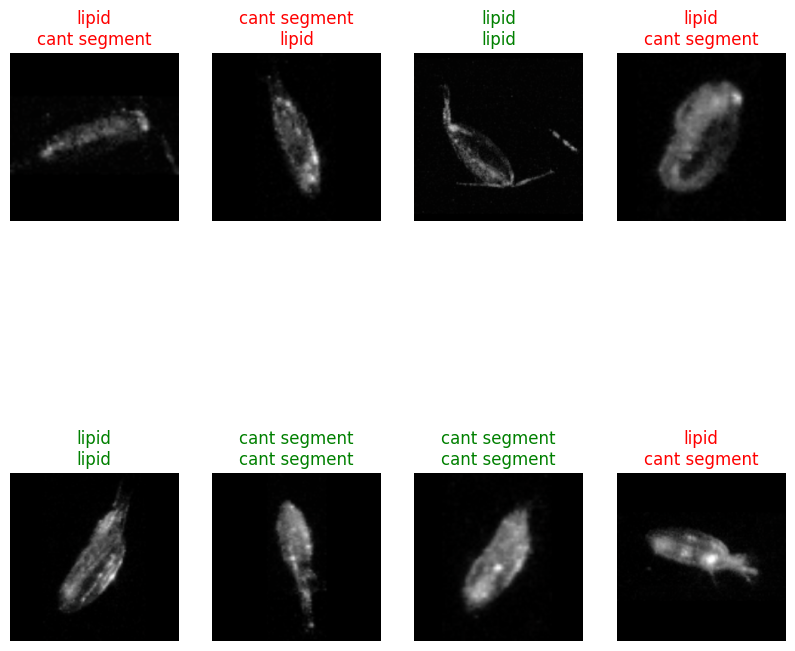

In [68]:
learn.summary()
# For exploring the model res") # Should this ults
learn.show_results(figsize =(10,10))

In [69]:
# Save load validate
learn.save("resnet34_lipid_classifier")  # Saves in 'models/resnet34_classifier.pth'

learn = cnn_learner(dls, resnet34, metrics=accuracy)  # Recreate the learner
learn.load("resnet34_lipid_classifier")  # Load saved model

valid_loss, valid_acc = learn.validate()
print(f"Validation Loss: {valid_loss:.4f}, Validation Accuracy: {valid_acc:.4f}")


Validation Loss: 0.6485, Validation Accuracy: 0.7027


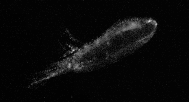

Predicted Class: lipid
Confidence Scores: TensorBase([0.2049, 0.7951])


In [70]:
# Test model with new data
img = PILImage.create("../uvp6_939_images/images_with_lipid/20211012-172206-798_1.png")  # Load an image
display(img)
pred, pred_idx, probs = learn.predict(img)

print(f"Predicted Class: {pred}")
print(f"Confidence Scores: {probs}")

In [ ]:
***** OLD SCRIPTS *****